# Lab 02 — Single transmitter P.1546 coverage

Compute field-strength grid for one HPHT site (HTZ coverage study analogue).

Text(0.5, 1.0, 'Coverage — Brussels HPHT')

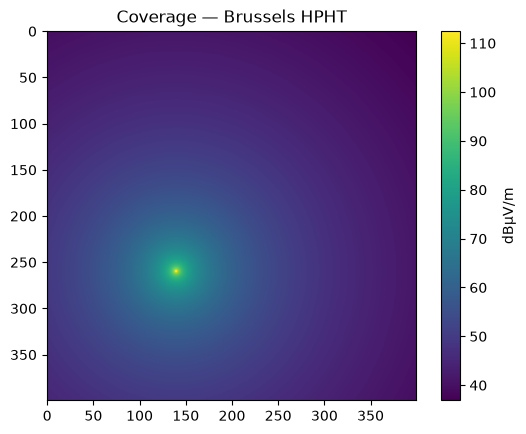

In [4]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from broadcast_planner.core.regions import DEFAULT_REGION, EXAMPLES_DIR
from broadcast_planner.core.grids import read_raster, make_grid
from broadcast_planner.core.sites import load_sites
from broadcast_planner.propagation.p1546_engine import compute_site_field_strength_fast

dem, _ = read_raster(DEFAULT_REGION.dem_path())
clutter, _ = read_raster(DEFAULT_REGION.clutter_path())
grid = make_grid(DEFAULT_REGION, resolution_m=250.0)
site = load_sites(EXAMPLES_DIR / 'sites.yaml').pilot()
result = compute_site_field_strength_fast(site, grid, dem, clutter)
plt.imshow(result.field_strength_dbuv_m, origin='upper')
plt.colorbar(label='dBµV/m')
plt.title(f'Coverage — {site.name}')